## 1. Install  XAI Libraries and Import Packages


In [6]:
# 1. Install XAI libraries and import packages
import os
import sys
import warnings
import subprocess
import pkgutil
from pathlib import Path

warnings.filterwarnings("ignore")

# Install shap & lime
for package in ["shap", "lime"]:
    if pkgutil.find_loader(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import shap
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Load the Diabetes Dataset


In [7]:
df = pd.read_csv("/content/diabetes_012_health_indicators_BRFSS2015.csv")
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 3. Dataset Overview


In [8]:
# Clean column names
df.columns = df.columns.str.strip()

# Drop missing rows
df = df.dropna()

# Create target safely
if "Diabetes_binary" in df.columns:
    y = df["Diabetes_binary"]
    X = df.drop(columns=["Diabetes_binary", "Diabetes_012"], errors="ignore")

elif "Diabetes_012" in df.columns:
    # Convert Diabetes_012 to binary:
    # 0 = no diabetes, 1 or 2 = diabetes/prediabetes
    y = (df["Diabetes_012"] > 0).astype(int)
    X = df.drop(columns=["Diabetes_012"], errors="ignore")

else:
    raise ValueError("No diabetes target column found")

print("Columns:", df.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

Columns: ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
X shape: (11690, 21)
y shape: (11690,)
Diabetes_012
0    9626
1    2064
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [10]:
# 3. Dataset overview: shape, columns, missing values, duplicates
print("Shape before cleaning:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values per column:")
display(df.isna().sum().to_frame("Missing Values"))

print("\nDuplicated rows before cleaning:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape before cleaning: (11690, 22)

Columns:
['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Missing values per column:


,Missing Values
Diabetes_012,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0



Duplicated rows before cleaning: 107
Shape after removing duplicates: (11583, 22)


In [11]:
# 4. Define the Binary Target Variable Correctly

# Clean column names from spaces
df.columns = df.columns.str.strip()

# Show all columns to verify
print("Dataset columns:")
print(df.columns.tolist())

# Create or use Diabetes_binary target
if "Diabetes_binary" in df.columns:
    target = "Diabetes_binary"

elif "Diabetes_012" in df.columns:
    df["Diabetes_binary"] = (df["Diabetes_012"] == 2).astype(int)
    target = "Diabetes_binary"

else:
    raise ValueError("No diabetes target column found. Expected Diabetes_binary or Diabetes_012.")

print("\nTarget column used:", target)

print("\nTarget distribution:")
display(df[target].value_counts().sort_index().to_frame("Count"))

display(
    (df[target].value_counts(normalize=True).sort_index() * 100)
    .round(2)
    .to_frame("Percentage")
)

Dataset columns:
['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Target column used: Diabetes_binary

Target distribution:


,Count
Diabetes_binary,
0,9728
1,1855


,Percentage
Diabetes_binary,
0,83.99
1,16.01


## 4. Define the Binary Diabetes Target


In [12]:
# 5. Separate Features and Target Without Data Leakage
X = df.drop(columns=["Diabetes_binary", "Diabetes_012"], errors="ignore")
y = df["Diabetes_binary"].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target values:", y.unique())

X shape: (11583, 21)
y shape: (11583,)
Target values: [0 1]


## 5. Separate Input Features and Target
This cell removes the target columns from the input features to avoid data leakage.

In [13]:
# 5. Separate features and target
exclude_cols = [target]

# Remove the original multiclass target if it exists and is not the active target.
if "Diabetes_012" in df.columns and target != "Diabetes_012":
    exclude_cols.append("Diabetes_012")

X = df.drop(columns=exclude_cols)
y = df[target].astype(int)

feature_info = pd.DataFrame({
    "Feature": X.columns,
    "Dtype": X.dtypes.astype(str).values,
    "Unique Values": [X[col].nunique() for col in X.columns],
    "Missing Values": [X[col].isna().sum() for col in X.columns]
})

display(feature_info)

,Feature,Dtype,Unique Values,Missing Values
0,HighBP,float64,2,0
1,HighChol,float64,2,0
2,CholCheck,float64,2,0
3,BMI,float64,54,0
4,Smoker,float64,2,0
5,Stroke,float64,2,0
6,HeartDiseaseorAttack,float64,2,0
7,PhysActivity,float64,2,0
8,Fruits,float64,2,0
9,Veggies,float64,2,0


## 6. EDA — Target Class Distribution


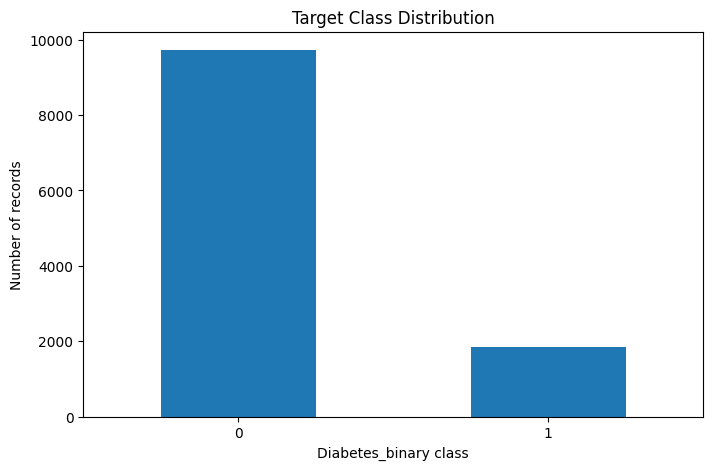

,Count,Percentage
Diabetes_binary,,
0,9728,83.99
1,1855,16.01


In [14]:
# 6. EDA: target class distribution
class_counts = y.value_counts().sort_index()
class_percent = (class_counts / class_counts.sum() * 100).round(2)

ax = class_counts.plot(kind="bar", title="Target Class Distribution")
ax.set_xlabel("Diabetes_binary class")
ax.set_ylabel("Number of records")
plt.xticks(rotation=0)
plt.show()

summary = pd.DataFrame({"Count": class_counts, "Percentage": class_percent})
display(summary)

## 7. EDA — Descriptive Statistics


In [15]:
# 7. EDA: descriptive statistics
display(X.describe().T)

,count,mean,std,min,25%,50%,75%,max
HighBP,11583.0,0.464733,0.498776,0.0,0.0,0.0,1.0,1.0
HighChol,11583.0,0.450747,0.497590,0.0,0.0,0.0,1.0,1.0
CholCheck,11583.0,0.961754,0.191797,0.0,1.0,1.0,1.0,1.0
BMI,11583.0,28.611327,6.381379,14.0,24.0,27.0,32.0,85.0
Smoker,11583.0,0.451696,0.497683,0.0,0.0,0.0,1.0,1.0
Stroke,11583.0,0.047829,0.213413,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,11583.0,0.103082,0.304079,0.0,0.0,0.0,0.0,1.0
PhysActivity,11583.0,0.737546,0.439987,0.0,0.0,1.0,1.0,1.0
Fruits,11583.0,0.600535,0.489810,0.0,0.0,1.0,1.0,1.0
Veggies,11583.0,0.799965,0.400043,0.0,1.0,1.0,1.0,1.0


## 8. EDA — Correlation with Diabetes Risk


Correlation between features and Diabetes_binary:


,Correlation with Diabetes_binary
GenHlth,0.292186
HighBP,0.258611
BMI,0.227617
DiffWalk,0.206500
HighChol,0.201008
Age,0.177347
PhysHlth,0.168285
HeartDiseaseorAttack,0.163186
Income,-0.159148
Stroke,0.120544


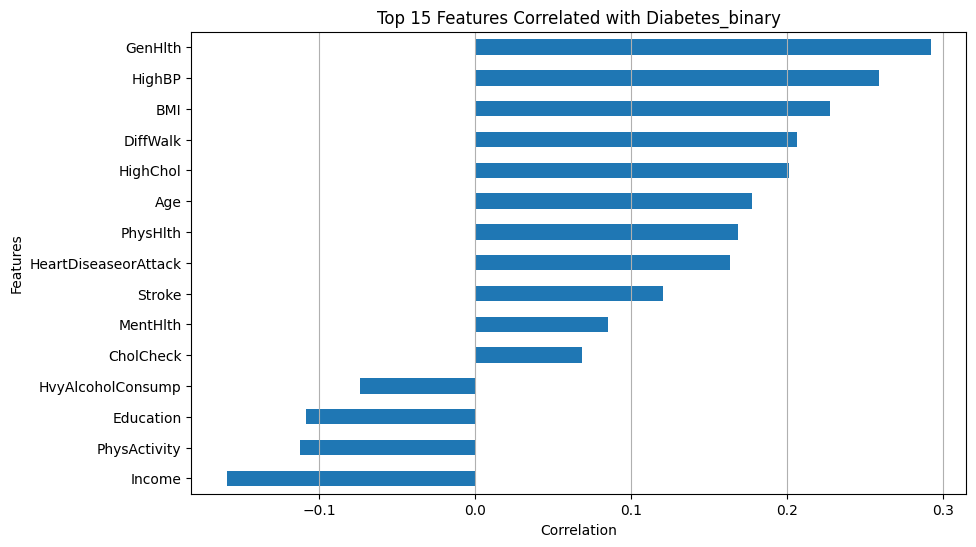

In [16]:
# EDA: Correlation Between Features and Target Without Leakage

correlation_df = df.drop(columns=["Diabetes_012"], errors="ignore")

correlation_with_target = correlation_df.corr(numeric_only=True)["Diabetes_binary"]
correlation_with_target = correlation_with_target.drop("Diabetes_binary")

correlation_with_target = correlation_with_target.reindex(
    correlation_with_target.abs().sort_values(ascending=False).index
)

print("Correlation between features and Diabetes_binary:")
display(correlation_with_target.to_frame("Correlation with Diabetes_binary"))

plt.figure(figsize=(10, 6))
correlation_with_target.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Features Correlated with Diabetes_binary")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.grid(axis="x")
plt.show()

## 9. EDA — Feature Distributions


Features plotted: ['GenHlth', 'HighBP', 'BMI', 'DiffWalk', 'HighChol', 'Age']


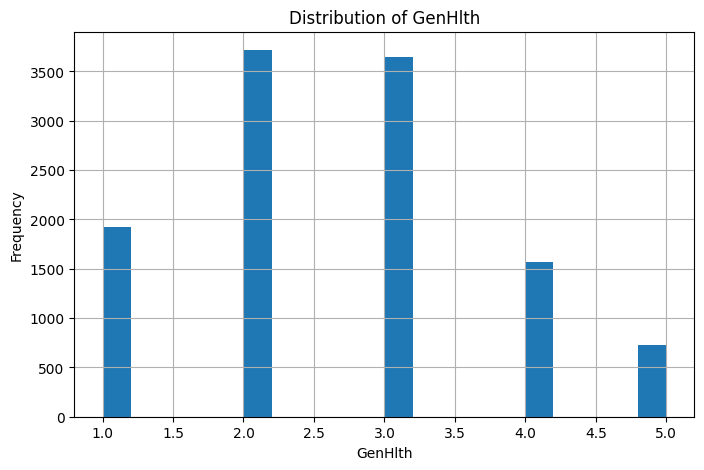

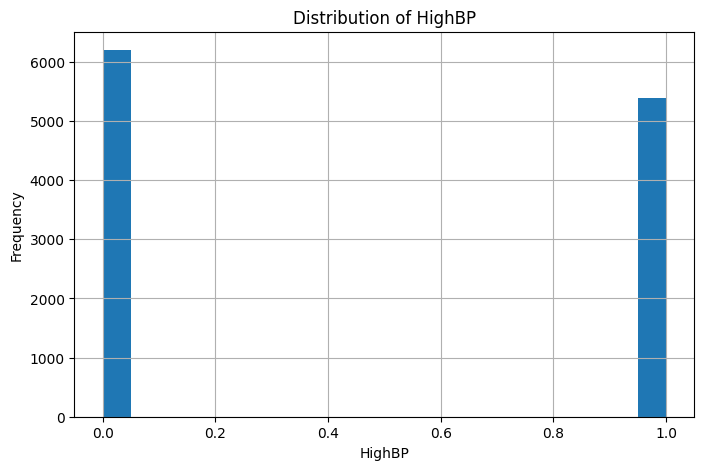

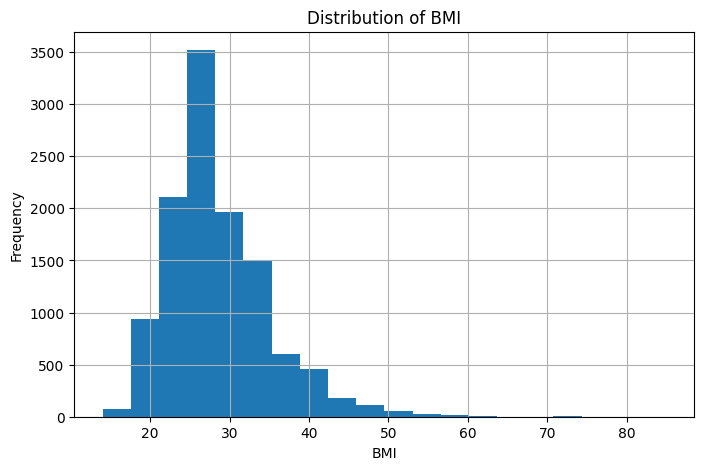

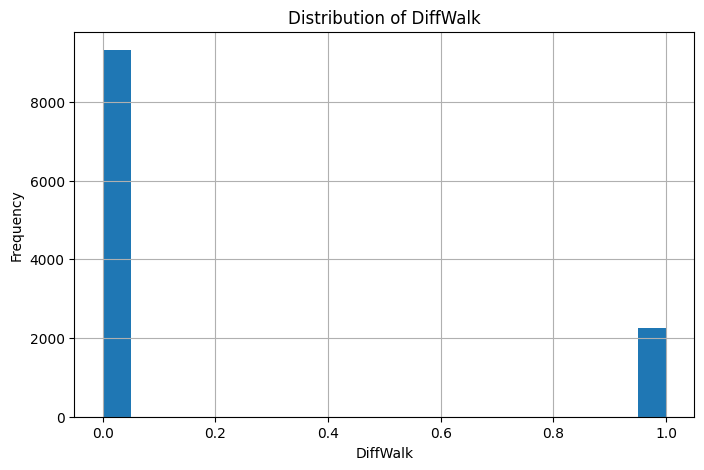

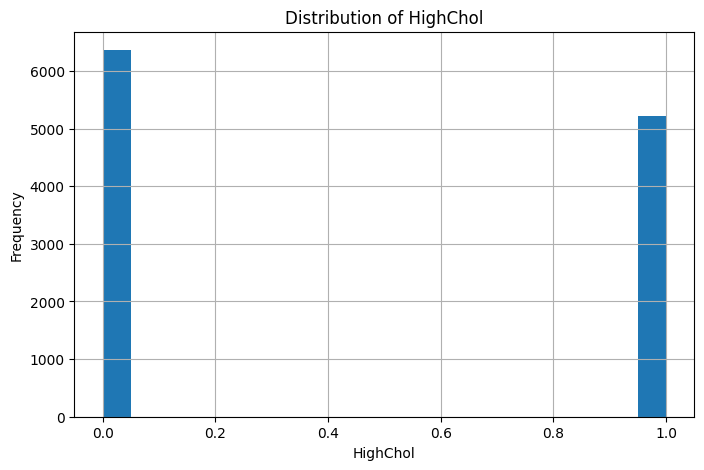

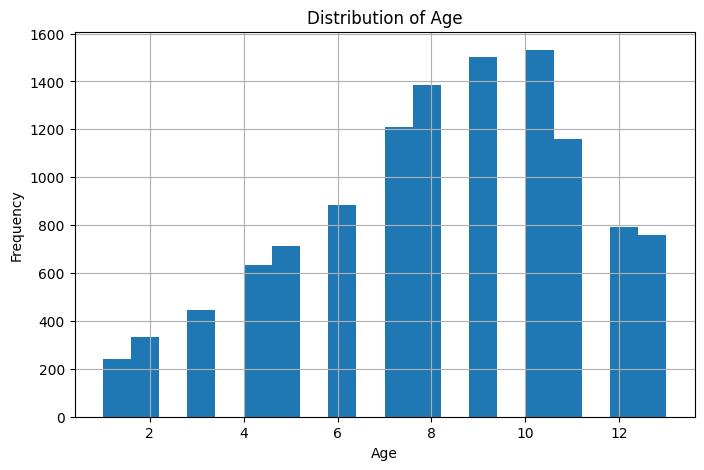

In [17]:
# 9. EDA: distributions of important features
top_distribution_features = correlation_with_target.head(6).index.tolist()
print("Features plotted:", top_distribution_features)

for feature in top_distribution_features:
    X[feature].hist(bins=20)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

## 10. Detect Binary and Numerical Features


In [18]:
# 10. Detect binary and numerical features
binary_features = [col for col in X.columns if X[col].dropna().nunique() <= 2]
numeric_features = [col for col in X.columns if col not in binary_features]

print("Binary features:", binary_features)
print("\nNumerical features:", numeric_features)
print("\nNumber of binary features:", len(binary_features))
print("Number of numerical features:", len(numeric_features))

Binary features: ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

Numerical features: ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

Number of binary features: 14
Number of numerical features: 7


## 11. Split the Dataset into Training and Testing Sets


In [19]:
# 11. Train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train_raw:", X_train_raw.shape)
print("X_test_raw :", X_test_raw.shape)
print("\nTraining target proportion:")
display(y_train.value_counts(normalize=True).sort_index().to_frame("Train Proportion"))
print("\nTesting target proportion:")
display(y_test.value_counts(normalize=True).sort_index().to_frame("Test Proportion"))

X_train_raw: (9266, 21)
X_test_raw : (2317, 21)

Training target proportion:


,Train Proportion
Diabetes_binary,
0,0.839845
1,0.160155



Testing target proportion:


,Test Proportion
Diabetes_binary,
0,0.839879
1,0.160121


## 12. Preprocessing Pipeline


In [20]:
# 12. Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("binary", binary_transformer, binary_features),
    ],
    remainder="drop"
)

X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

processed_feature_names = numeric_features + binary_features

X_train_processed_df = pd.DataFrame(X_train_processed, columns=processed_feature_names, index=X_train_raw.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=processed_feature_names, index=X_test_raw.index)

print("Processed training data:", X_train_processed_df.shape)
print("Processed testing data :", X_test_processed_df.shape)
display(X_train_processed_df.head())

Processed training data: (9266, 21)
Processed testing data : (2317, 21)


,BMI,GenHlth,MentHlth,PhysHlth,Age,Education,Income,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex
6379,-0.413208,0.357646,-0.450891,0.247786,-0.037831,0.001634,0.525079,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4712,3.322037,2.170031,0.182805,2.766750,-0.037831,0.001634,-2.279984,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
3448,-0.413208,0.357646,-0.450891,-0.518856,0.293808,-1.007614,-1.344963,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
61,-0.257572,1.263838,-0.450891,0.028745,0.957085,-1.007614,-1.812474,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
9732,-0.413208,-0.548547,0.436283,-0.518856,-0.037831,1.010881,0.992590,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0


## 13. Feature Engineering and Feature Selection


In [21]:
# ============================================================
# 13. Feature Engineering and Random Forest Embedded Feature Selection
# ============================================================

from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# Make copies of processed training and testing data
X_train_fe = X_train_processed_df.copy()
X_test_fe = X_test_processed_df.copy()

# ------------------------------------------------------------
# Feature Engineering
# ------------------------------------------------------------

# 1. Cardiometabolic risk score
cardio_cols = ["HighBP", "HighChol", "HeartDiseaseorAttack", "Stroke"]
available_cardio_cols = [col for col in cardio_cols if col in X_train_fe.columns]

if len(available_cardio_cols) > 0:
    X_train_fe["Cardiometabolic_Risk_Score"] = X_train_fe[available_cardio_cols].sum(axis=1)
    X_test_fe["Cardiometabolic_Risk_Score"] = X_test_fe[available_cardio_cols].sum(axis=1)

# 2. Lifestyle risk score
lifestyle_cols = []

if "Smoker" in X_train_fe.columns:
    lifestyle_cols.append("Smoker")

if "PhysActivity" in X_train_fe.columns:
    X_train_fe["No_Physical_Activity"] = 1 - X_train_fe["PhysActivity"]
    X_test_fe["No_Physical_Activity"] = 1 - X_test_fe["PhysActivity"]
    lifestyle_cols.append("No_Physical_Activity")

if "Fruits" in X_train_fe.columns:
    X_train_fe["Low_Fruit_Intake"] = 1 - X_train_fe["Fruits"]
    X_test_fe["Low_Fruit_Intake"] = 1 - X_test_fe["Fruits"]
    lifestyle_cols.append("Low_Fruit_Intake")

if "Veggies" in X_train_fe.columns:
    X_train_fe["Low_Veggie_Intake"] = 1 - X_train_fe["Veggies"]
    X_test_fe["Low_Veggie_Intake"] = 1 - X_test_fe["Veggies"]
    lifestyle_cols.append("Low_Veggie_Intake")

if "HvyAlcoholConsump" in X_train_fe.columns:
    lifestyle_cols.append("HvyAlcoholConsump")

if len(lifestyle_cols) > 0:
    X_train_fe["Lifestyle_Risk_Score"] = X_train_fe[lifestyle_cols].sum(axis=1)
    X_test_fe["Lifestyle_Risk_Score"] = X_test_fe[lifestyle_cols].sum(axis=1)

# 3. Health limitation score
health_cols = ["GenHlth", "DiffWalk", "PhysHlth", "MentHlth"]
available_health_cols = [col for col in health_cols if col in X_train_fe.columns]

if len(available_health_cols) > 0:
    X_train_fe["Health_Limitation_Score"] = X_train_fe[available_health_cols].sum(axis=1)
    X_test_fe["Health_Limitation_Score"] = X_test_fe[available_health_cols].sum(axis=1)

# 4. BMI and Age interaction
if "BMI" in X_train_fe.columns and "Age" in X_train_fe.columns:
    X_train_fe["BMI_Age_Interaction"] = X_train_fe["BMI"] * X_train_fe["Age"]
    X_test_fe["BMI_Age_Interaction"] = X_test_fe["BMI"] * X_test_fe["Age"]

# ------------------------------------------------------------
# Random Forest Embedded Feature Selection
# ------------------------------------------------------------

rf_feature_selector = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_feature_selector.fit(X_train_fe, y_train)

feature_scores = pd.DataFrame({
    "Feature": X_train_fe.columns,
    "Random Forest Importance": rf_feature_selector.feature_importances_
}).sort_values("Random Forest Importance", ascending=False)

# Select the top 10 most important features
k = min(10, X_train_fe.shape[1])
selected_features = feature_scores.head(k)["Feature"].tolist()

# Final selected training and testing sets
X_train = X_train_fe[selected_features].copy()
X_test = X_test_fe[selected_features].copy()
feature_names = selected_features

print("Selected features:")
print(selected_features)

display(feature_scores)

print("\nFinal X_train shape:", X_train.shape)
print("Final X_test shape :", X_test.shape)

Selected features:
['Cardiometabolic_Risk_Score', 'BMI', 'GenHlth', 'Health_Limitation_Score', 'Age', 'BMI_Age_Interaction', 'HighBP', 'Income', 'HighChol', 'PhysHlth']


,Feature,Random Forest Importance
21,Cardiometabolic_Risk_Score,0.111322
0,BMI,0.109127
1,GenHlth,0.105257
26,Health_Limitation_Score,0.103881
4,Age,0.091581
27,BMI_Age_Interaction,0.085378
7,HighBP,0.070450
6,Income,0.046966
8,HighChol,0.033795
3,PhysHlth,0.033485



Final X_train shape: (9266, 10)
Final X_test shape : (2317, 10)


## 14. Define Evaluation and Explainability Helper Functions


In [22]:
# 14. Helper functions for evaluation and explainability
def evaluate_classifier(model, X_test, y_test, model_name):
    """Evaluate a binary classifier with common performance metrics and plots."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }

    display(pd.DataFrame([metrics]).round(4))
    print("Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))

    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=["No Diabetes", "Diabetes"])
    plt.title(f"{model_name} — Confusion Matrix")
    plt.show()

    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{model_name} — ROC Curve")
    plt.show()

    return metrics


def plot_top_importances(importances, names, title, top_n=15):
    """Plot and return a sorted feature-importance table."""
    importance_df = pd.DataFrame({"Feature": list(names), "Importance": list(importances)})
    importance_df = importance_df.sort_values("Importance", ascending=False).reset_index(drop=True)

    plot_df = importance_df.head(top_n).sort_values("Importance")
    ax = plot_df.plot(kind="barh", x="Feature", y="Importance", legend=False, title=title)
    ax.set_xlabel("Importance")
    plt.show()

    return importance_df


def get_binary_shap_values(model, X_sample):
    """Return SHAP values for the positive diabetes class in a robust way."""
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    if isinstance(shap_values, list):
        return shap_values[1] if len(shap_values) > 1 else shap_values[0]

    shap_array = np.array(shap_values)
    if shap_array.ndim == 3:
        # New SHAP versions often return shape: samples × features × classes.
        if shap_array.shape[2] > 1:
            return shap_array[:, :, 1]
        # Some versions return shape: classes × samples × features.
        if shap_array.shape[0] > 1:
            return shap_array[1]

    return shap_array

## 15. Build and Train the Random Forest Model


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": [300, 500, 700],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=20,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print("Best Random Forest Params:", rf_search.best_params_)
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Best Random Forest Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}
Random Forest Results
Accuracy: 0.8433318946914113
Precision: 0.5454545454545454
Recall: 0.1293800539083558
F1-score: 0.20915032679738563
ROC-AUC: 0.8036611142352964


## 16. Evaluate the Random Forest Model


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.8433,0.5455,0.1294,0.2092,0.8037


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.86      0.98      0.91      1946
    Diabetes       0.55      0.13      0.21       371

    accuracy                           0.84      2317
   macro avg       0.70      0.55      0.56      2317
weighted avg       0.81      0.84      0.80      2317



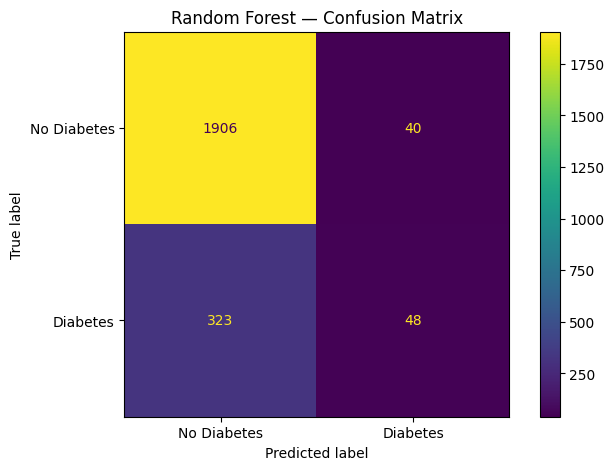

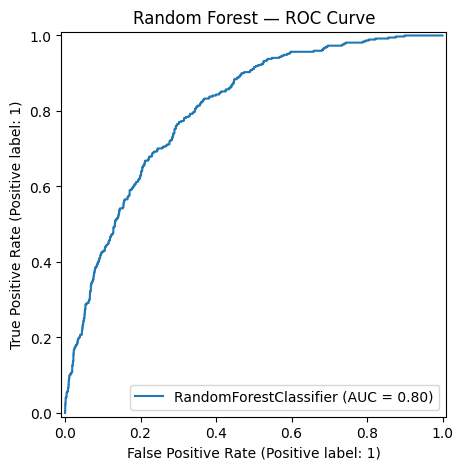

In [25]:
# 16. Evaluate the Random Forest model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

rf_metrics = evaluate_classifier(best_rf, X_test, y_test, "Random Forest")

In [27]:
model = best_rf
feature_names = X_train.columns

## Technique 1 — Model-Intrinsic Feature Importance
Random Forest feature importance is calculated by averaging impurity reduction across all trees in the ensemble.

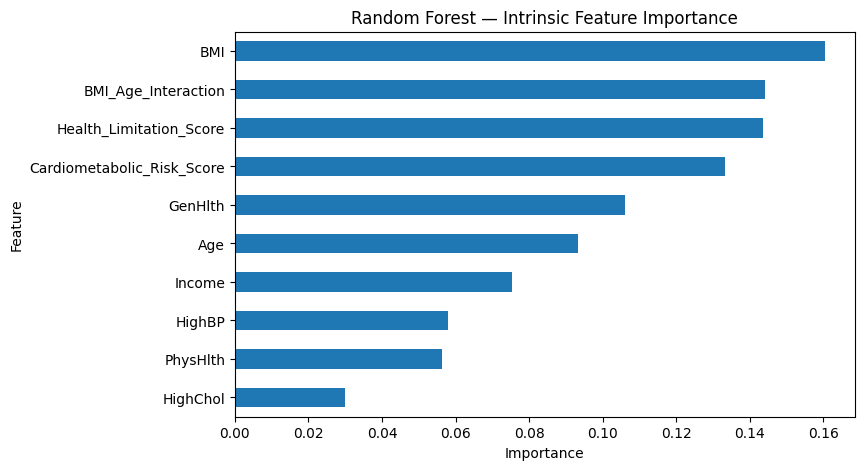

,Feature,Importance
0,BMI,0.160532
1,BMI_Age_Interaction,0.144063
2,Health_Limitation_Score,0.143497
3,Cardiometabolic_Risk_Score,0.133355
4,GenHlth,0.106039
5,Age,0.093144
6,Income,0.075199
7,HighBP,0.057813
8,PhysHlth,0.056362
9,HighChol,0.029997


In [28]:
# 17. XAI Technique 1: Model-intrinsic feature importance
intrinsic_importance_df = plot_top_importances(
    model.feature_importances_,
    feature_names,
    "Random Forest — Intrinsic Feature Importance"
)
display(intrinsic_importance_df)

## Technique 2 — Permutation Importance
Permutation importance evaluates how much the trained Random Forest depends on each feature for predictive performance.

,Feature,Mean Importance,Std
0,Cardiometabolic_Risk_Score,0.035799,0.005845
2,GenHlth,0.033661,0.008816
1,BMI,0.028376,0.004516
4,Age,0.021031,0.003016
6,HighBP,0.007681,0.002347
7,Income,0.004615,0.002496
3,Health_Limitation_Score,0.004540,0.002296
8,HighChol,0.001312,0.001918
9,PhysHlth,0.001280,0.000982
5,BMI_Age_Interaction,-0.003178,0.002719


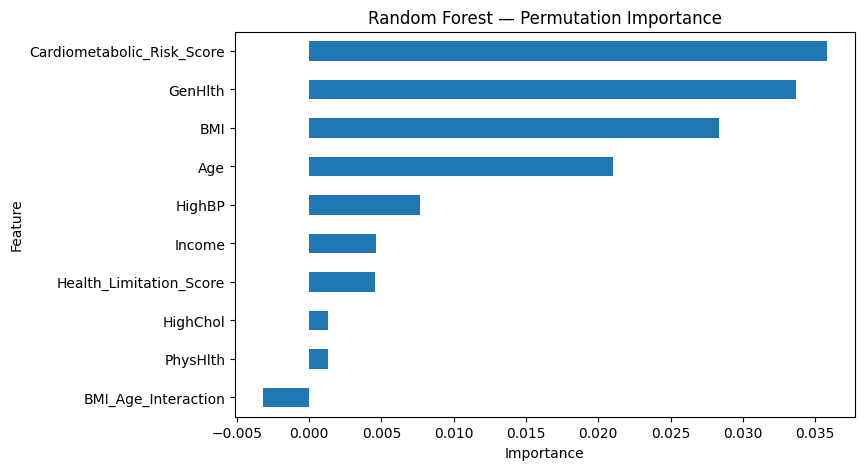

,Feature,Importance
0,Cardiometabolic_Risk_Score,0.035799
1,GenHlth,0.033661
2,BMI,0.028376
3,Age,0.021031
4,HighBP,0.007681
5,Income,0.004615
6,Health_Limitation_Score,0.004540
7,HighChol,0.001312
8,PhysHlth,0.001280
9,BMI_Age_Interaction,-0.003178


In [29]:
# 18. XAI Technique 2: Permutation importance
perm_result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std
}).sort_values("Mean Importance", ascending=False)

display(permutation_importance_df)
plot_top_importances(
    permutation_importance_df["Mean Importance"].values,
    permutation_importance_df["Feature"].values,
    "Random Forest — Permutation Importance"
)

## 19.Technique 3 — Partial Dependence Plots PDP
PDP shows the average relationship between important health indicators and predicted diabetes probability.

PDP features: ['Cardiometabolic_Risk_Score', 'GenHlth', 'BMI']


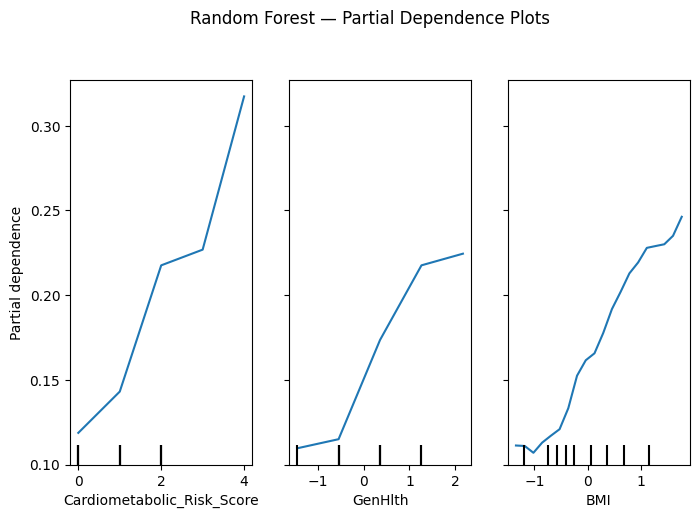

In [30]:
# 19. XAI Technique 3: Partial Dependence Plots
top_pdp_features = permutation_importance_df.head(3)["Feature"].tolist()
print("PDP features:", top_pdp_features)

PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=top_pdp_features,
    kind="average",
    grid_resolution=20
)
plt.suptitle("Random Forest — Partial Dependence Plots", y=1.02)
plt.show()

## Technique 4 — SHAP Explanations
SHAP explains feature contributions for the Random Forest globally and locally.

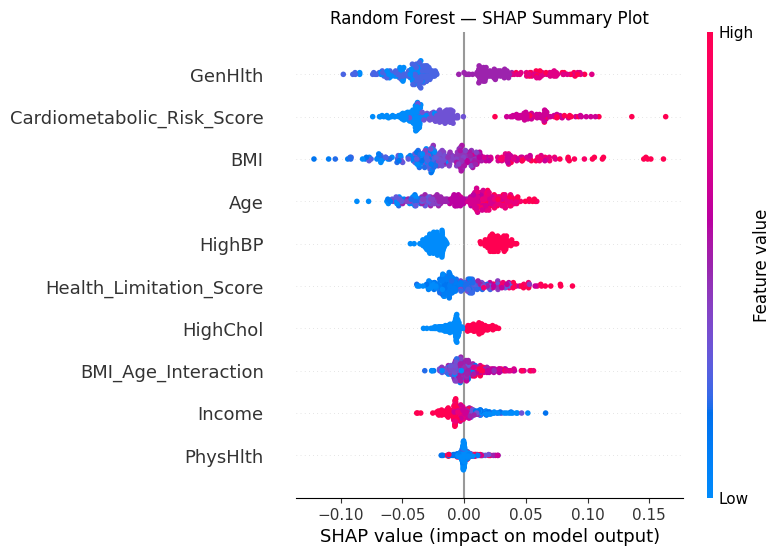

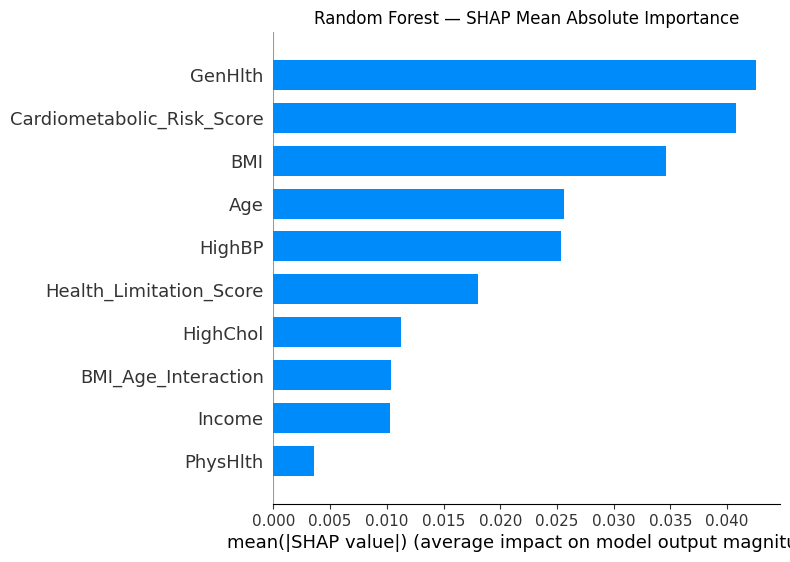

In [31]:
# 20. XAI Technique 4: SHAP explanations
X_shap = X_test.sample(n=min(300, len(X_test)), random_state=RANDOM_STATE)
shap_values_to_plot = get_binary_shap_values(model, X_shap)

shap.summary_plot(shap_values_to_plot, X_shap, show=False)
plt.title("Random Forest — SHAP Summary Plot")
plt.show()

shap.summary_plot(shap_values_to_plot, X_shap, plot_type="bar", show=False)
plt.title("Random Forest — SHAP Mean Absolute Importance")
plt.show()

## Technique 5 — LIME Local Explanation
LIME explains one selected sample by approximating the Random Forest prediction locally with a simpler model.

Explained test instance index: 0
True class: 0
Predicted probabilities [No Diabetes, Diabetes]: [0.91195777 0.08804223]


,Feature Condition,Local Weight
0,GenHlth <= -0.55,-0.071790
1,1.00 < Cardiometabolic_Risk_Score <= 2.00,0.053973
2,0.00 < HighBP <= 1.00,0.025297
3,0.06 < Income <= 0.99,-0.021039
4,Health_Limitation_Score <= -1.52,-0.017879
5,0.00 < HighChol <= 1.00,0.012657
6,-0.70 < Age <= -0.04,-0.010911
7,PhysHlth <= -0.52,-0.008212
8,-0.26 < BMI <= 0.52,0.007931
9,-0.03 < BMI_Age_Interaction <= 0.29,-0.000128


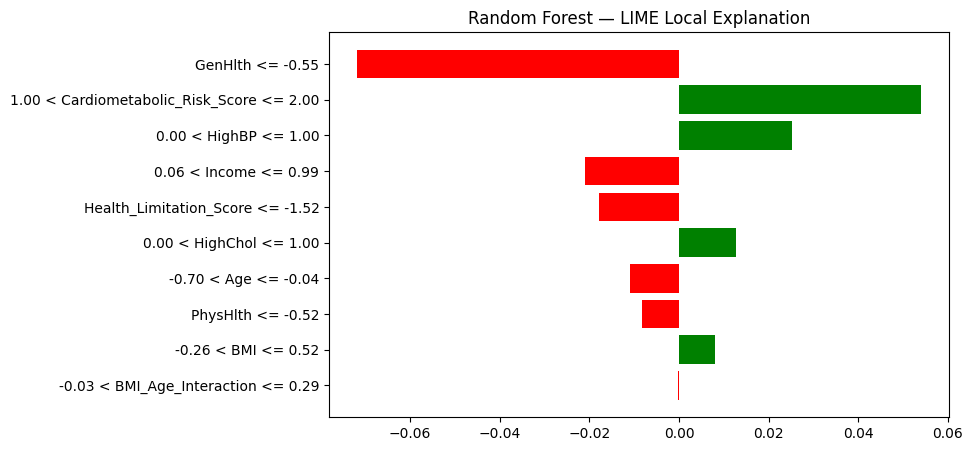

In [32]:
# 21. XAI Technique 5: LIME local explanation
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=feature_names,
    class_names=["No Diabetes", "Diabetes"],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

instance_index = 0
lime_exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[instance_index].values,
    predict_fn=model.predict_proba,
    num_features=10
)

print("Explained test instance index:", instance_index)
print("True class:", y_test.iloc[instance_index])
print("Predicted probabilities [No Diabetes, Diabetes]:", model.predict_proba(X_test.iloc[[instance_index]])[0])

display(pd.DataFrame(lime_exp.as_list(), columns=["Feature Condition", "Local Weight"]))
lime_exp.as_pyplot_figure()
plt.title("Random Forest — LIME Local Explanation")
plt.show()

## Technique 6 — Explain One Tree from the Random Forest
Although the whole Random Forest is an ensemble, one tree can be visualized to give a simplified view of the logic learned by the model.

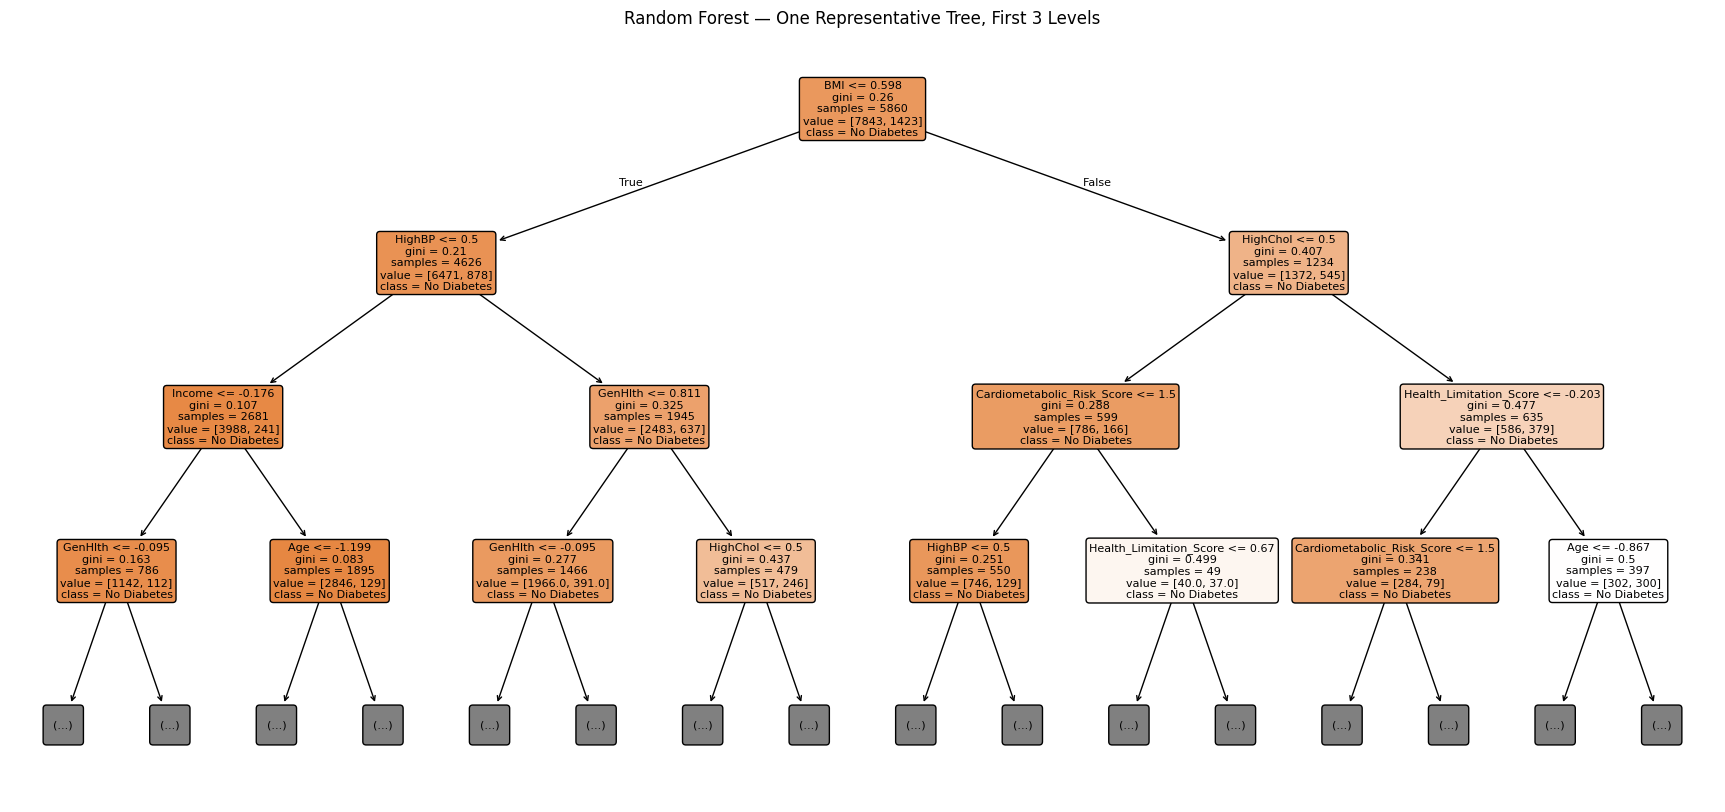

In [33]:
# 22. XAI Technique 6: Visualize one tree from the Random Forest
from sklearn.tree import plot_tree

single_tree = model.estimators_[0]

plt.figure(figsize=(22, 10))
plot_tree(
    single_tree,
    feature_names=feature_names,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Random Forest — One Representative Tree, First 3 Levels")
plt.show()

## 23. Compare the XAI Techniques Used with Random Forest


In [34]:
# 23. XAI comparison table for Random Forest
xai_comparison = pd.DataFrame({
    "XAI Tool": [
        "Intrinsic Feature Importance",
        "Permutation Importance",
        "PDP",
        "SHAP",
        "LIME",
        "Representative Tree"
    ],
    "Explanation Type": [
        "Global feature ranking",
        "Global feature ranking",
        "Global feature effect",
        "Global + local contribution",
        "Local explanation",
        "Simplified visual explanation"
    ],
    "Main Use": [
        "Ranks features averaged over all trees.",
        "Measures performance drop after feature shuffling.",
        "Shows average feature effect on diabetes probability.",
        "Shows direction and strength of feature contributions.",
        "Explains one individual prediction.",
        "Shows one sample tree from the ensemble."
    ],
    "Limitation": [
        "Can favor features used often in splits.",
        "May be affected by correlated features.",
        "May hide interactions and individual differences.",
        "Can be slower for large datasets.",
        "Only explains one sample at a time.",
        "One tree does not represent the full forest exactly."
    ]
})

display(xai_comparison)

,XAI Tool,Explanation Type,Main Use,Limitation
0,Intrinsic Feature Importance,Global feature ranking,Ranks features averaged over all trees.,Can favor features used often in splits.
1,Permutation Importance,Global feature ranking,Measures performance drop after feature shuffl...,May be affected by correlated features.
2,PDP,Global feature effect,Shows average feature effect on diabetes proba...,May hide interactions and individual differences.
3,SHAP,Global + local contribution,Shows direction and strength of feature contri...,Can be slower for large datasets.
4,LIME,Local explanation,Explains one individual prediction.,Only explains one sample at a time.
5,Representative Tree,Simplified visual explanation,Shows one sample tree from the ensemble.,One tree does not represent the full forest ex...
